# Implement Naive Bayes Classification

#### 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# same dataset as the other practicals
df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # headers had random trailing spaces, this fixes that
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [2]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

# result column had PASS/Pass/pass all mixed together, fixing that here
df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

# just filling gaps with mean/mode, nothing fancy
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])  # cant use a row with no roll no
print(df.isnull().sum())
print("\nRESULT value counts:")
print(df['RESULT'].value_counts())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64

RESULT value counts:
RESULT
PASS         66
FAIL          4
DISCHARGE     1
Name: count, dtype: int64


#### 3. Define target (y)
Predicting **RESULT** again like the earlier practicals. Dropping any class with less than 2 rows since the model literally cannot learn from just 1 example (ran into this issue in practical 9 as well).

In [3]:
MIN_SAMPLES_PER_CLASS = 2

class_counts = df['RESULT'].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

if rare_classes:
    print(f"dropping these classes, not enough samples: {rare_classes}")
    df = df[~df['RESULT'].isin(rare_classes)]

print(df['RESULT'].value_counts())

dropping these classes, not enough samples: ['DISCHARGE']
RESULT
PASS    66
FAIL     4
Name: count, dtype: int64


#### 4. Encode target and define features

In [4]:
from sklearn.preprocessing import LabelEncoder

le_result = LabelEncoder()
df['RESULT_ENCODED'] = le_result.fit_transform(df['RESULT'])
print(dict(zip(le_result.classes_, le_result.transform(le_result.classes_))))  # just to see what got mapped to what

X = df[numeric_cols]
y = df['RESULT_ENCODED']

{'FAIL': np.int64(0), 'PASS': np.int64(1)}


#### 5. Train-test split

In [7]:
from sklearn.model_selection import train_test_split

# only stratify if every class actually has enough rows for it, otherwise it throws an error
min_class_count = y.value_counts().min()
stratify_arg = y if min_class_count >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56, 5)
Test shape: (14, 5)


#### 6. Train the Naive Bayes model
Using GaussianNB since our features (marks) are continuous numbers, not counts or categories.

In [8]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)  # no scaling needed for NB, it doesn't care about feature ranges

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[ 3.,53.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.05,0.95]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.443e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['SOFTWARE ENGINEER','TOC','COMPUTER NETWORK','MACHINE LEARNING', 'DATA WAREHOUSE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 5)","[[14.67,18.67,10.67,19. ,41.33], [44.57,45.82,45.63,46.45,45.23]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 5)","[[110.22,160.22,118.22,128. ,329.56], [125.21,166.39,161.78,210.53,174.95]]"


#### 7. Evaluate the model

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# zero_division=0 just to stop the warning spam for the small classes
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_result.classes_, zero_division=0))

Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.50      1.00      0.67         1
        PASS       1.00      0.92      0.96        13

    accuracy                           0.93        14
   macro avg       0.75      0.96      0.81        14
weighted avg       0.96      0.93      0.94        14



#### 8. Confusion matrix

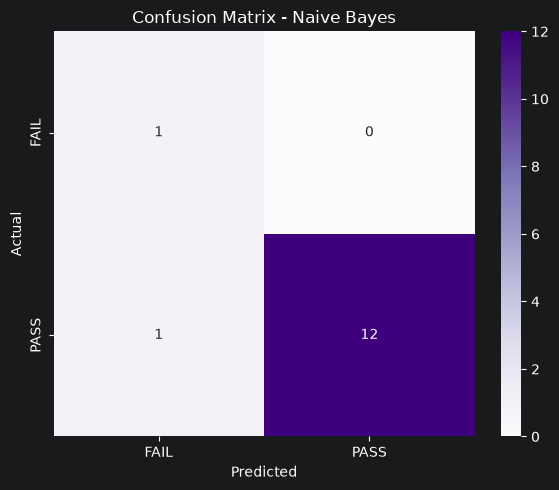

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### 9. Predicted probabilities
NB gives probabilities for each class based on Bayes theorem, worth looking at a few rows.

In [12]:
probabilities = nb_model.predict_proba(X_test)
proba_df = pd.DataFrame(probabilities, columns=le_result.classes_)
proba_df.head()  # each row should add up to 1

,FAIL,PASS
0,1.710323e-06,0.999998
1,1.440159e-13,1.000000
2,6.777605e-04,0.999322
3,5.977688e-02,0.940223
4,6.550431e-06,0.999993


#### 10. Predict on a new student
Same test example used in the other practicals so results are easy to compare.

In [13]:
new_student = pd.DataFrame([[45, 50, 48, 52, 47]], columns=numeric_cols)

prediction = nb_model.predict(new_student)
prediction_proba = nb_model.predict_proba(new_student)

print("Predicted result:", le_result.inverse_transform(prediction)[0])
print("Class probabilities:", dict(zip(le_result.classes_, prediction_proba[0])))

Predicted result: PASS
Class probabilities: {'FAIL': np.float64(2.0980948721083805e-09), 'PASS': np.float64(0.9999999979019059)}
